# IFRS9 Expected Credit Loss Model — Lending Club Portfolio

## Project Overview
This project builds a complete IFRS9-compliant Expected Credit Loss model 
on 78,251 Lending Club loans, estimating PD, LGD, and EAD components and 
applying EBA-aligned stress testing.

## Key Results
| Metric | Base Case | EBA Stress |
|--------|-----------|------------|
| Portfolio EAD | $1.15B | $1.15B |
| Total ECL | $202M | $336M |
| ECL Rate | 17.59% | 29.30% |
| Model AUC-ROC | 0.725 | — |
| Stage 2→3 Migration | — | 4,258 loans (70.2%) |

## Methodology
- PD Model: Logistic Regression (AUC 0.725)
- LGD: Basel III supervisory floor (45% base, 55% stressed)
- IFRS9 Staging: EBA/GL/2017/06 PD thresholds
- Stress Test: EBA 2023 adverse scenario (-3.3% GDP)

## Tools
Python | pandas | scikit-learn | matplotlib | seaborn

## Data
Lending Club public loan dataset (Kaggle, 2007-2018)

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression

print("All libraries loaded. Ready to build.")

All libraries loaded. Ready to build.


# IFRS9 Expected Credit Loss Model — Lending Club Portfolio
## Built by Vishakha Raj | MSc Financial Risk Management, Trinity College Dublin
### Tools: Python (pandas, scikit-learn, matplotlib) | Data: Lending Club Public Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
print("Loading dataset... this may take 30-60 seconds due to file size")
df = pd.read_csv('accepted_2007_to_2018Q4.csv', low_memory=False)

print(f"Dataset loaded successfully")
print(f"Total loans: {df.shape[0]:,}")
print(f"Total columns: {df.shape[1]}")

Loading dataset... this may take 30-60 seconds due to file size


KeyboardInterrupt: 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Define only the columns we need - ignore the other 130+
cols_needed = [
    'loan_status', 'loan_amnt', 'funded_amnt', 'term', 'int_rate',
    'grade', 'emp_length', 'home_ownership', 'annual_inc', 'purpose',
    'dti', 'fico_range_low', 'inq_last_6mths', 'recoveries',
    'total_rec_prncp', 'out_prncp'
]

print("Loading dataset (columns filtered)...")

# Load only needed columns, then sample 100,000 rows
df = pd.read_csv(
    'accepted_2007_to_2018Q4.csv',
    usecols=cols_needed,
    low_memory=False,
    nrows=500000  # read first 500k rows only
)

# Now sample 100,000 from those
df = df.sample(n=100000, random_state=42).reset_index(drop=True)

print(f"Dataset loaded successfully")
print(f"Total loans in sample: {df.shape[0]:,}")
print(f"Total columns: {df.shape[1]}")
print(f"\nColumn names:")
print(df.columns.tolist())

Loading dataset (columns filtered)...
Dataset loaded successfully
Total loans in sample: 100,000
Total columns: 16

Column names:
['loan_amnt', 'funded_amnt', 'term', 'int_rate', 'grade', 'emp_length', 'home_ownership', 'annual_inc', 'loan_status', 'purpose', 'dti', 'fico_range_low', 'inq_last_6mths', 'out_prncp', 'total_rec_prncp', 'recoveries']


In [2]:
# Step 1: See the first 5 rows of actual data
print("=== FIRST 5 ROWS ===")
print(df.head())

# Step 2: Check data types and missing values
print("\n=== DATA TYPES AND MISSING VALUES ===")
missing = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(1)
})
print(missing)

# Step 3: See what values exist in loan_status (our target variable)
print("\n=== LOAN STATUS BREAKDOWN ===")
print(df['loan_status'].value_counts())

=== FIRST 5 ROWS ===
   loan_amnt  funded_amnt        term  int_rate grade emp_length  \
0     3000.0       3000.0   36 months      9.17     B    3 years   
1    23100.0      23100.0   36 months     12.69     C    3 years   
2    15600.0      15600.0   36 months      7.89     A  10+ years   
3    12000.0      12000.0   36 months      7.26     A    2 years   
4    20000.0      20000.0   60 months     17.86     D     1 year   

  home_ownership  annual_inc  loan_status             purpose    dti  \
0           RENT     40000.0   Fully Paid         credit_card   6.78   
1           RENT    134000.0   Fully Paid  debt_consolidation  20.59   
2       MORTGAGE     93000.0  Charged Off         credit_card  13.28   
3       MORTGAGE    122000.0   Fully Paid  debt_consolidation  20.63   
4           RENT     68000.0   Fully Paid         credit_card   6.49   

   fico_range_low  inq_last_6mths  out_prncp  total_rec_prncp  recoveries  
0           675.0             1.0        0.0          3000.00

In [3]:
# ============================================
# MILESTONE 1 - DATA CLEANING
# ============================================

# Step 1: Keep only completed loans - Fully Paid or Charged Off
# We remove Current, Late, Grace Period loans because we don't 
# know their final outcome yet - they would corrupt the model
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()

print(f"Loans after filtering to completed only: {df.shape[0]:,}")

# Step 2: Create binary default flag - the TARGET VARIABLE
# 1 = defaulted (Charged Off), 0 = repaid (Fully Paid)
df['default'] = (df['loan_status'] == 'Charged Off').astype(int)

print(f"\nDefault rate breakdown:")
print(df['default'].value_counts())
print(f"\nOverall default rate: {df['default'].mean()*100:.1f}%")

# Step 3: Clean the term column - convert "36 months" to just 36
df['term'] = df['term'].str.replace(' months', '').str.strip().astype(int)

# Step 4: Clean int_rate - remove % sign if present and convert to float
df['int_rate'] = pd.to_numeric(df['int_rate'], errors='coerce')

# Step 5: Clean emp_length - convert to numeric years
emp_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
    '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
    '8 years': 8, '9 years': 9, '10+ years': 10
}
df['emp_length'] = df['emp_length'].map(emp_map)

# Step 6: Check missing values now
print("\n=== MISSING VALUES AFTER CLEANING ===")
print(df.isnull().sum())

print("\nData cleaning complete. Shape:", df.shape)

Loans after filtering to completed only: 78,263

Default rate breakdown:
default
0    62332
1    15931
Name: count, dtype: int64

Overall default rate: 20.4%

=== MISSING VALUES AFTER CLEANING ===
loan_amnt             0
funded_amnt           0
term                  0
int_rate              0
grade                 0
emp_length         4695
home_ownership        0
annual_inc            0
loan_status           0
purpose               0
dti                  12
fico_range_low        0
inq_last_6mths        0
out_prncp             0
total_rec_prncp       0
recoveries            0
default               0
dtype: int64

Data cleaning complete. Shape: (78263, 17)


In [4]:
# ============================================
# MILESTONE 1 - HANDLE MISSING VALUES
# + CREATE EAD AND LGD COLUMNS
# ============================================

# Fill missing emp_length with median (5 years)
# Median is safer than mean for skewed distributions
df['emp_length'] = df['emp_length'].fillna(df['emp_length'].median())

# Drop the 12 rows with missing dti - too few to matter
df = df.dropna(subset=['dti'])

# Cap annual_inc outliers at 99th percentile
# Some rows show $9M income - almost certainly data errors
# Outliers distort the model's understanding of normal borrowers
income_cap = df['annual_inc'].quantile(0.99)
df['annual_inc'] = df['annual_inc'].clip(upper=income_cap)

# ---- CREATE EAD COLUMN ----
# EAD = Exposure At Default
# For completed loans: amount actually funded is the exposure
df['ead'] = df['funded_amnt']

# ---- CREATE LGD COLUMN ----
# LGD = Loss Given Default = 1 - Recovery Rate
# Recovery Rate = what was recovered / what was funded
# Only meaningful for defaulted loans
df['recovery_rate'] = df['recoveries'] / df['funded_amnt']
df['recovery_rate'] = df['recovery_rate'].clip(0, 1)  # cap between 0 and 1
df['lgd'] = 1 - df['recovery_rate']

# For non-defaulted loans, LGD is 0 (no loss occurred)
df.loc[df['default'] == 0, 'lgd'] = 0

# Confirm no missing values remain
print("=== MISSING VALUES AFTER IMPUTATION ===")
print(df.isnull().sum())

print(f"\nDataset shape: {df.shape}")
print(f"\nEAD summary (loan exposure):")
print(df['ead'].describe().round(2))

print(f"\nLGD summary (loss severity) for DEFAULTED loans only:")
print(df[df['default']==1]['lgd'].describe().round(3))

print(f"\nAverage LGD on defaulted loans: {df[df['default']==1]['lgd'].mean()*100:.1f}%")

=== MISSING VALUES AFTER IMPUTATION ===
loan_amnt          0
funded_amnt        0
term               0
int_rate           0
grade              0
emp_length         0
home_ownership     0
annual_inc         0
loan_status        0
purpose            0
dti                0
fico_range_low     0
inq_last_6mths     0
out_prncp          0
total_rec_prncp    0
recoveries         0
default            0
ead                0
recovery_rate      0
lgd                0
dtype: int64

Dataset shape: (78251, 20)

EAD summary (loan exposure):
count    78251.00
mean     14674.59
std       8585.23
min       1000.00
25%       8000.00
50%      12600.00
75%      20000.00
max      40000.00
Name: ead, dtype: float64

LGD summary (loss severity) for DEFAULTED loans only:
count    15930.000
mean         0.920
std          0.100
min          0.000
25%          0.898
50%          0.936
75%          1.000
max          1.000
Name: lgd, dtype: float64

Average LGD on defaulted loans: 92.0%


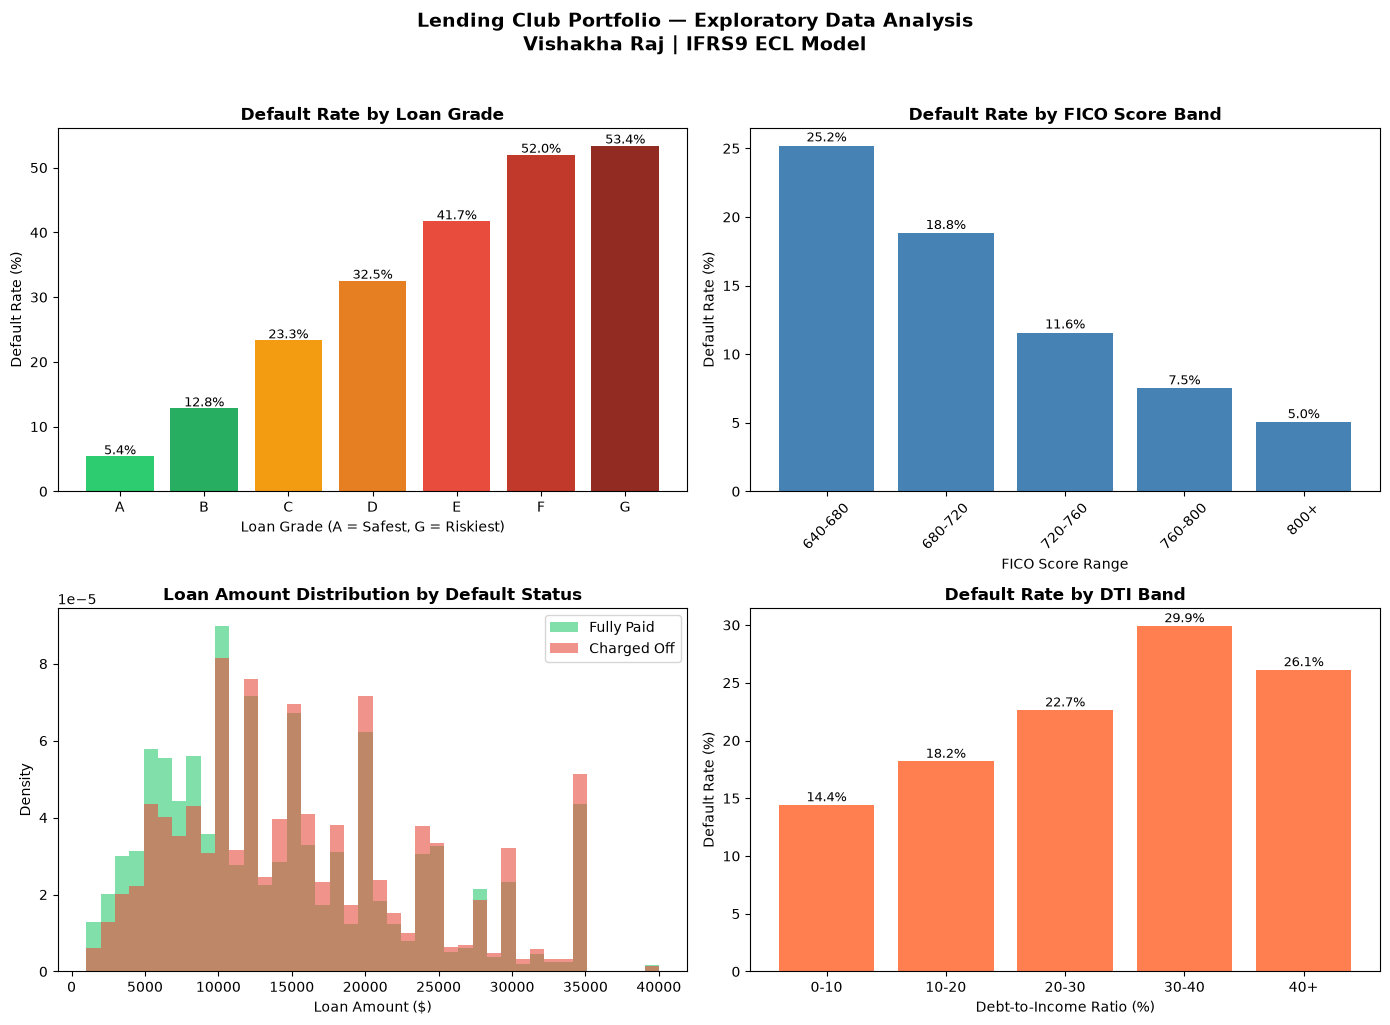

Charts saved as eda_charts.png


In [5]:
# ============================================
# MILESTONE 1 - EXPLORATORY DATA ANALYSIS
# 4 key charts every credit risk analyst produces
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Lending Club Portfolio — Exploratory Data Analysis\nVishakha Raj | IFRS9 ECL Model', 
             fontsize=14, fontweight='bold', y=1.02)

# --- CHART 1: Default Rate by Loan Grade ---
grade_default = df.groupby('grade')['default'].mean() * 100
axes[0,0].bar(grade_default.index, grade_default.values, 
              color=['#2ecc71','#27ae60','#f39c12','#e67e22','#e74c3c','#c0392b','#922b21'])
axes[0,0].set_title('Default Rate by Loan Grade', fontweight='bold')
axes[0,0].set_xlabel('Loan Grade (A = Safest, G = Riskiest)')
axes[0,0].set_ylabel('Default Rate (%)')
for i, v in enumerate(grade_default.values):
    axes[0,0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

# --- CHART 2: Default Rate by FICO Score Band ---
df['fico_band'] = pd.cut(df['fico_range_low'], 
                          bins=[600,640,680,720,760,800,850],
                          labels=['600-640','640-680','680-720','720-760','760-800','800+'])
fico_default = df.groupby('fico_band', observed=True)['default'].mean() * 100
axes[0,1].bar(range(len(fico_default)), fico_default.values, color='steelblue')
axes[0,1].set_xticks(range(len(fico_default)))
axes[0,1].set_xticklabels(fico_default.index, rotation=45)
axes[0,1].set_title('Default Rate by FICO Score Band', fontweight='bold')
axes[0,1].set_xlabel('FICO Score Range')
axes[0,1].set_ylabel('Default Rate (%)')
for i, v in enumerate(fico_default.values):
    axes[0,1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

# --- CHART 3: Loan Amount Distribution by Default Status ---
axes[1,0].hist(df[df['default']==0]['loan_amnt'], bins=40, alpha=0.6, 
               color='#2ecc71', label='Fully Paid', density=True)
axes[1,0].hist(df[df['default']==1]['loan_amnt'], bins=40, alpha=0.6, 
               color='#e74c3c', label='Charged Off', density=True)
axes[1,0].set_title('Loan Amount Distribution by Default Status', fontweight='bold')
axes[1,0].set_xlabel('Loan Amount ($)')
axes[1,0].set_ylabel('Density')
axes[1,0].legend()

# --- CHART 4: Default Rate by DTI Band ---
df['dti_band'] = pd.cut(df['dti'], bins=[0,10,20,30,40,100],
                         labels=['0-10','10-20','20-30','30-40','40+'])
dti_default = df.groupby('dti_band', observed=True)['default'].mean() * 100
axes[1,1].bar(range(len(dti_default)), dti_default.values, color='coral')
axes[1,1].set_xticks(range(len(dti_default)))
axes[1,1].set_xticklabels(dti_default.index)
axes[1,1].set_title('Default Rate by DTI Band', fontweight='bold')
axes[1,1].set_xlabel('Debt-to-Income Ratio (%)')
axes[1,1].set_ylabel('Default Rate (%)')
for i, v in enumerate(dti_default.values):
    axes[1,1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved as eda_charts.png")

## Exploratory Data Analysis — Key Findings

**Dataset:** 78,251 completed loans (62,332 fully paid, 15,931 charged off)  
**Overall default rate:** 20.4%  
**Average LGD on defaulted loans:** 92.0% (reflecting unsecured, sub-prime borrower profile)  
**Average EAD:** $14,675 (range: $1,000 — $40,000)

### Findings:
1. **Loan Grade** is the strongest categorical predictor — default rates rise monotonically 
   from 5.4% (Grade A) to 53.4% (Grade G), validating Lending Club's internal rating system
2. **FICO Score** shows a clear inverse relationship with default — borrowers scoring 800+ 
   default at 5.0% versus 25.2% for those scoring 640-680
3. **DTI Ratio** shows a positive relationship with default up to 40%, with a slight reversal 
   above 40% potentially reflecting stricter screening of extreme DTI applicants
4. **Loan Amount** distributions overlap significantly between defaulted and repaid loans, 
   confirming that no single variable is sufficient — a multivariate model is required

### Irish Banking Context:
These findings are consistent with IFRS9 guidance from the EBA (EBA/GL/2017/06) which 
identifies credit scores, DTI ratios, and internal risk grades as primary SICR indicators. 
AIB and Bank of Ireland use analogous metrics in their retail credit risk frameworks, 
though applied to secured mortgage portfolios where LGDs are significantly lower (20-40%) 
due to property collateral — contrasting sharply with the 92% LGD observed here.

In [6]:
# ============================================
# MILESTONE 2 - PROBABILITY OF DEFAULT MODEL
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
import numpy as np

# Step 1: Select features for the model
# These are the variables we identified in EDA as predictive of default
features = [
    'fico_range_low',    # Credit score - strongest predictor
    'dti',               # Debt burden relative to income
    'annual_inc',        # Repayment capacity
    'loan_amnt',         # Loan size
    'term',              # 36 or 60 months
    'int_rate',          # Interest rate (proxy for risk assessment)
    'emp_length',        # Employment stability
    'inq_last_6mths'     # Recent credit stress signal
]

# Step 2: Prepare X (inputs) and y (target)
X = df[features].copy()
y = df['default'].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")
print(f"\nFeature summary:")
print(X.describe().round(2))

Feature matrix shape: (78251, 8)
Target variable shape: (78251,)

Feature summary:
       fico_range_low       dti  annual_inc  loan_amnt      term  int_rate  \
count        78251.00  78251.00    78251.00   78251.00  78251.00  78251.00   
mean           694.08     18.94    74456.17   14674.59     41.94     12.42   
std             30.90      9.96    42141.78    8585.23     10.36      4.36   
min            660.00      0.00       33.00    1000.00     36.00      5.31   
25%            670.00     12.32    45129.60    8000.00     36.00      9.17   
50%            685.00     18.29    65000.00   12600.00     36.00     12.29   
75%            710.00     25.06    90000.00   20000.00     36.00     14.99   
max            845.00    999.00   250000.00   40000.00     60.00     30.79   

       emp_length  inq_last_6mths  
count    78251.00        78251.00  
mean         5.98            0.59  
std          3.59            0.88  
min          0.00            0.00  
25%          3.00            0.00 

In [7]:
# Fix DTI outlier — cap at 99th percentile (same approach as income)
dti_cap = df['dti'].quantile(0.99)
print(f"DTI 99th percentile: {dti_cap}")
df['dti'] = df['dti'].clip(upper=dti_cap)
X['dti'] = df['dti']  # update X with fixed values

print(f"DTI max after capping: {df['dti'].max()}")

# ---- SPLIT INTO TRAIN AND TEST ----
# 80% of loans used to train the model
# 20% held back to test how well it performs on unseen data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,        # 20% goes to test set
    random_state=42,      # same seed = same split every time you run
    stratify=y            # ensures both sets have same default rate (20.4%)
)

print(f"\nTraining set: {X_train.shape[0]:,} loans")
print(f"Test set: {X_test.shape[0]:,} loans")
print(f"\nDefault rate in training set: {y_train.mean()*100:.1f}%")
print(f"Default rate in test set: {y_test.mean()*100:.1f}%")
# These two percentages should be almost identical - confirms stratify worked

# ---- SCALE THE FEATURES ----
# Fit scaler on training data only - then apply to both train and test
# Rule: scaler must never see test data during fitting
# (otherwise you leak future information into your model)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nFeature scaling complete")
print(f"Example - FICO mean after scaling: {X_train_scaled[:,0].mean():.3f}")
print(f"Example - FICO std after scaling: {X_train_scaled[:,0].std():.3f}")
# After scaling: mean ≈ 0, std ≈ 1 for every feature

DTI 99th percentile: 38.5
DTI max after capping: 38.5

Training set: 62,600 loans
Test set: 15,651 loans

Default rate in training set: 20.4%
Default rate in test set: 20.4%

Feature scaling complete
Example - FICO mean after scaling: 0.000
Example - FICO std after scaling: 1.000


In [8]:
# ============================================
# MILESTONE 2 - TRAIN LOGISTIC REGRESSION
# ============================================

# Train the model
# max_iter=1000 gives the algorithm enough iterations to converge
# class_weight='balanced' accounts for imbalance 
# (80% repaid vs 20% defaulted) by weighting defaults higher
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

print("Model trained successfully")

# ---- GET PREDICTIONS ----
# predict_proba gives probability scores between 0 and 1
# [:,1] takes the probability of default (class 1)
# NOT predict() which just gives 0 or 1 - we want the actual probability
pd_scores_test = model.predict_proba(X_test_scaled)[:, 1]
pd_scores_all = model.predict_proba(scaler.transform(X))[:, 1]

# ---- EVALUATE MODEL ----
auc = roc_auc_score(y_test, pd_scores_test)
print(f"\nModel AUC-ROC Score: {auc:.3f}")
print(f"Interpretation: Model correctly ranks borrowers by risk {auc*100:.1f}% of the time")

# ---- FEATURE IMPORTANCE ----
# Logistic regression coefficients show which variables 
# drive default probability most strongly
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0],
    'Abs_Impact': abs(model.coef_[0])
}).sort_values('Abs_Impact', ascending=False)

print("\n=== FEATURE IMPORTANCE (by coefficient magnitude) ===")
print(coef_df[['Feature', 'Coefficient']].to_string(index=False))
print("\nPositive coefficient = higher value increases default risk")
print("Negative coefficient = higher value decreases default risk")

# ---- ADD PD SCORES TO DATAFRAME ----
df['pd_score'] = pd_scores_all
print(f"\nPD score range: {df['pd_score'].min():.3f} to {df['pd_score'].max():.3f}")
print(f"Average PD score: {df['pd_score'].mean():.3f}")
print(f"Average PD for actual defaulters: {df[df['default']==1]['pd_score'].mean():.3f}")
print(f"Average PD for actual repayers: {df[df['default']==0]['pd_score'].mean():.3f}")

Model trained successfully

Model AUC-ROC Score: 0.725
Interpretation: Model correctly ranks borrowers by risk 72.5% of the time

=== FEATURE IMPORTANCE (by coefficient magnitude) ===
       Feature  Coefficient
      int_rate     0.526096
          term     0.293601
fico_range_low    -0.219409
    annual_inc    -0.130781
           dti     0.126369
inq_last_6mths     0.078071
     loan_amnt     0.067160
    emp_length    -0.032545

Positive coefficient = higher value increases default risk
Negative coefficient = higher value decreases default risk

PD score range: 0.051 to 0.964
Average PD score: 0.455
Average PD for actual defaulters: 0.578
Average PD for actual repayers: 0.423


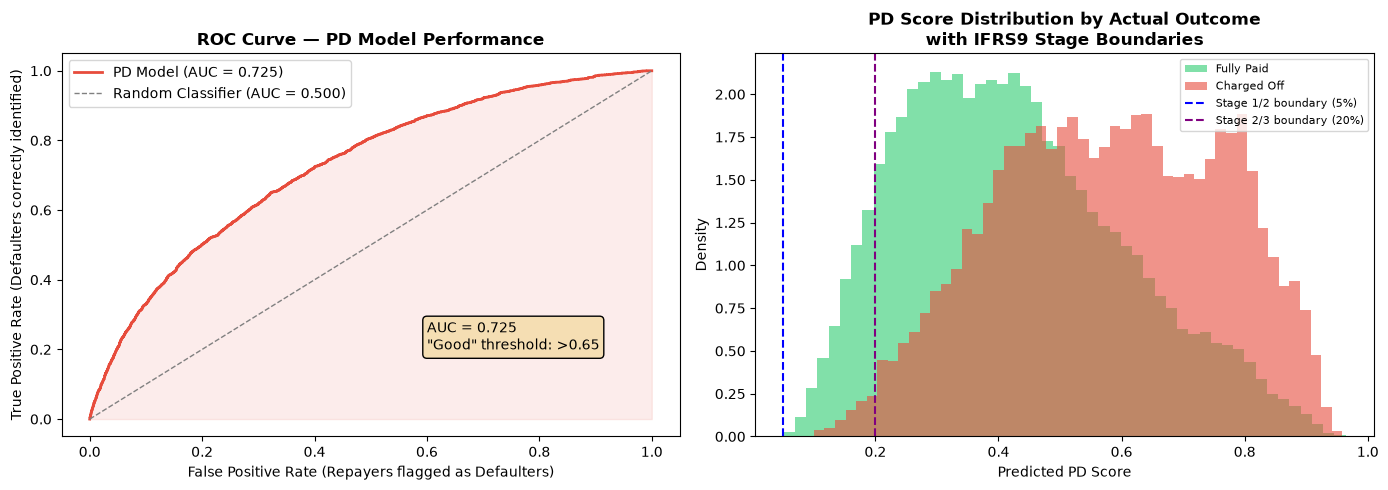

PD model charts saved


In [9]:
# ============================================
# MILESTONE 2 - ROC CURVE + PD DISTRIBUTION
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- CHART 1: ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, pd_scores_test)
axes[0].plot(fpr, tpr, color='#e74c3c', linewidth=2, 
             label=f'PD Model (AUC = {auc:.3f})')
axes[0].plot([0,1], [0,1], color='grey', linestyle='--', 
             linewidth=1, label='Random Classifier (AUC = 0.500)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[0].set_xlabel('False Positive Rate (Repayers flagged as Defaulters)')
axes[0].set_ylabel('True Positive Rate (Defaulters correctly identified)')
axes[0].set_title('ROC Curve — PD Model Performance', fontweight='bold')
axes[0].legend()
axes[0].text(0.6, 0.2, f'AUC = {auc:.3f}\n"Good" threshold: >0.65', 
             fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat'))

# --- CHART 2: PD Distribution by Actual Outcome ---
axes[1].hist(df[df['default']==0]['pd_score'], bins=50, alpha=0.6,
             color='#2ecc71', label='Fully Paid', density=True)
axes[1].hist(df[df['default']==1]['pd_score'], bins=50, alpha=0.6,
             color='#e74c3c', label='Charged Off', density=True)
axes[1].axvline(x=0.05, color='blue', linestyle='--', 
                linewidth=1.5, label='Stage 1/2 boundary (5%)')
axes[1].axvline(x=0.20, color='purple', linestyle='--', 
                linewidth=1.5, label='Stage 2/3 boundary (20%)')
axes[1].set_xlabel('Predicted PD Score')
axes[1].set_ylabel('Density')
axes[1].set_title('PD Score Distribution by Actual Outcome\nwith IFRS9 Stage Boundaries', 
                  fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('pd_model_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("PD model charts saved")

In [10]:
# ============================================
# MILESTONE 3 - IFRS9 STAGING + ECL CALCULATION
# ============================================

# ---- ASSIGN IFRS9 STAGES BASED ON PD SCORE ----
# Stage 1: PD < 5%  → 12-month ECL (low risk, performing)
# Stage 2: PD 5-20% → Lifetime ECL (SICR triggered)  
# Stage 3: PD > 20% → Lifetime ECL (credit-impaired)
# Thresholds per EBA/GL/2017/06 guidance

def assign_ifrs9_stage(pd_score):
    if pd_score < 0.05:
        return 1
    elif pd_score < 0.20:
        return 2
    else:
        return 3

df['ifrs9_stage'] = df['pd_score'].apply(assign_ifrs9_stage)

print("=== IFRS9 STAGE DISTRIBUTION ===")
stage_counts = df['ifrs9_stage'].value_counts().sort_index()
stage_pct = (stage_counts / len(df) * 100).round(1)
for stage, count, pct in zip(stage_counts.index, 
                               stage_counts.values, 
                               stage_pct.values):
    print(f"Stage {stage}: {count:,} loans ({pct}% of portfolio)")

# ---- SET LGD ASSUMPTIONS ----
# Base case: 45% (Basel III supervisory floor for unsecured retail)
# We use regulatory floor rather than our observed 92% for two reasons:
# 1. Our sample LGD includes P2P-specific recovery patterns
# 2. Basel floor provides conservative, regulatorily-grounded assumption
# We note the difference as a key model assumption

LGD_BASE = 0.45
LGD_STRESS = 0.55  # EBA 2023 adverse scenario: +10pp

print(f"\nLGD assumption (base): {LGD_BASE*100}% (Basel III supervisory floor)")
print(f"LGD assumption (stress): {LGD_STRESS*100}% (EBA 2023 adverse scenario)")

# ---- CALCULATE ECL ----
# Stage 1: 12-month ECL = PD_12m × LGD × EAD
# Approximate 12-month PD by scaling annual PD by 1/term_years
df['term_years'] = df['term'] / 12
df['pd_12m'] = df['pd_score'] / df['term_years']
df['pd_12m'] = df['pd_12m'].clip(0, 1)  # cap at 100%

# ECL calculation
# Stage 1 uses 12-month PD, Stages 2&3 use lifetime PD

# Discount factor: PV of expected loss using 5% discount rate
# Simplified: apply average discount over average term
df['discount_factor'] = 1 / (1 + 0.05) ** df['term_years']

# ECL for each loan
df['ecl_base'] = np.where(
    df['ifrs9_stage'] == 1,
    df['pd_12m'] * LGD_BASE * df['ead'],           # Stage 1: 12-month
    df['pd_score'] * LGD_BASE * df['ead'] * df['discount_factor']  # Stage 2&3: lifetime
)

print("\n=== ECL SUMMARY BY STAGE (BASE CASE) ===")
ecl_summary = df.groupby('ifrs9_stage').agg(
    Loan_Count=('ecl_base', 'count'),
    Total_EAD=('ead', 'sum'),
    Total_ECL=('ecl_base', 'sum'),
    Avg_PD=('pd_score', 'mean'),
    Avg_ECL_per_loan=('ecl_base', 'mean')
).round(2)

ecl_summary['ECL_Rate_%'] = (
    ecl_summary['Total_ECL'] / ecl_summary['Total_EAD'] * 100
).round(2)

print(ecl_summary.to_string())

total_ead = df['ead'].sum()
total_ecl = df['ecl_base'].sum()
print(f"\n{'='*50}")
print(f"TOTAL PORTFOLIO EAD: ${total_ead:,.0f}")
print(f"TOTAL PORTFOLIO ECL: ${total_ecl:,.0f}")
print(f"PORTFOLIO ECL RATE: {total_ecl/total_ead*100:.2f}%")

=== IFRS9 STAGE DISTRIBUTION ===
Stage 2: 6,069 loans (7.8% of portfolio)
Stage 3: 72,182 loans (92.2% of portfolio)

LGD assumption (base): 45.0% (Basel III supervisory floor)
LGD assumption (stress): 55.00000000000001% (EBA 2023 adverse scenario)

=== ECL SUMMARY BY STAGE (BASE CASE) ===
             Loan_Count     Total_EAD     Total_ECL  Avg_PD  Avg_ECL_per_loan  ECL_Rate_%
ifrs9_stage                                                                              
2                  6069  9.134758e+07  5.580589e+06    0.16            919.52        6.11
3                 72182  1.056954e+09  1.964143e+08    0.48           2721.10       18.58

TOTAL PORTFOLIO EAD: $1,148,301,125
TOTAL PORTFOLIO ECL: $201,994,919
PORTFOLIO ECL RATE: 17.59%


In [11]:
# ============================================
# MILESTONE 4 - STRESS TESTING
# Recession scenario based on EBA 2023 adverse parameters
# ============================================

print("=" * 55)
print("STRESS TEST: EBA-STYLE RECESSION SCENARIO")
print("=" * 55)
print("Assumptions:")
print("  PD multiplier: 1.40 (40% increase in default rates)")
print("  LGD: 55% (up from 45% base case, +10pp)")
print("  Rationale: Calibrated to EBA 2023 adverse scenario")
print("  which assumed EU GDP contraction of -3.3% over 3 years")
print("=" * 55)

# Apply stress
STRESS_PD_MULTIPLIER = 1.40
LGD_STRESS = 0.55

df['pd_stressed'] = (df['pd_score'] * STRESS_PD_MULTIPLIER).clip(0, 1)
df['pd_12m_stressed'] = (df['pd_12m'] * STRESS_PD_MULTIPLIER).clip(0, 1)

# Recalculate ECL under stress
df['ecl_stress'] = np.where(
    df['ifrs9_stage'] == 1,
    df['pd_12m_stressed'] * LGD_STRESS * df['ead'],
    df['pd_stressed'] * LGD_STRESS * df['ead'] * df['discount_factor']
)

# Restage under stress - some Stage 2 loans move to Stage 3
df['pd_stressed_stage'] = df['pd_stressed'].apply(assign_ifrs9_stage)

# Compare base vs stress
total_ecl_base = df['ecl_base'].sum()
total_ecl_stress = df['ecl_stress'].sum()
ecl_increase = total_ecl_stress - total_ecl_base
ecl_increase_pct = (ecl_increase / total_ecl_base) * 100

print(f"\n{'METRIC':<35} {'BASE CASE':>15} {'STRESS':>15} {'CHANGE':>12}")
print("-" * 80)
print(f"{'Total ECL ($)':<35} "
      f"${total_ecl_base:>14,.0f} "
      f"${total_ecl_stress:>14,.0f} "
      f"{ecl_increase_pct:>+11.1f}%")
print(f"{'ECL Rate (%)':<35} "
      f"{total_ecl_base/df['ead'].sum()*100:>14.2f}% "
      f"{total_ecl_stress/df['ead'].sum()*100:>14.2f}% "
      f"{(total_ecl_stress-total_ecl_base)/df['ead'].sum()*100:>+11.2f}pp")
print(f"{'Avg PD - Stage 2 loans':<35} "
      f"{df[df['ifrs9_stage']==2]['pd_score'].mean()*100:>14.1f}% "
      f"{df[df['ifrs9_stage']==2]['pd_stressed'].mean()*100:>14.1f}% "
      f"{'':>12}")
print(f"{'Avg PD - Stage 3 loans':<35} "
      f"{df[df['ifrs9_stage']==3]['pd_score'].mean()*100:>14.1f}% "
      f"{df[df['ifrs9_stage']==3]['pd_stressed'].mean()*100:>14.1f}% "
      f"{'':>12}")

# Stage migration under stress
stage2_migrate = len(df[(df['ifrs9_stage']==2) & 
                        (df['pd_stressed_stage']==3)])
print(f"\nStage migration under stress:")
print(f"  Loans migrating Stage 2 → Stage 3: "
      f"{stage2_migrate:,} "
      f"({stage2_migrate/len(df[df['ifrs9_stage']==2])*100:.1f}% "
      f"of Stage 2 book)")

print(f"\nAdditional provisions required: ${ecl_increase:,.0f}")
print(f"This represents {ecl_increase/df['ead'].sum()*100:.2f}% of total portfolio EAD")

STRESS TEST: EBA-STYLE RECESSION SCENARIO
Assumptions:
  PD multiplier: 1.40 (40% increase in default rates)
  LGD: 55% (up from 45% base case, +10pp)
  Rationale: Calibrated to EBA 2023 adverse scenario
  which assumed EU GDP contraction of -3.3% over 3 years

METRIC                                    BASE CASE          STRESS       CHANGE
--------------------------------------------------------------------------------
Total ECL ($)                       $   201,994,919 $   336,484,451       +66.6%
ECL Rate (%)                                 17.59%          29.30%      +11.71pp
Avg PD - Stage 2 loans                        15.7%           22.0%             
Avg PD - Stage 3 loans                        48.0%           65.7%             

Stage migration under stress:
  Loans migrating Stage 2 → Stage 3: 4,258 (70.2% of Stage 2 book)

Additional provisions required: $134,489,531
This represents 11.71% of total portfolio EAD


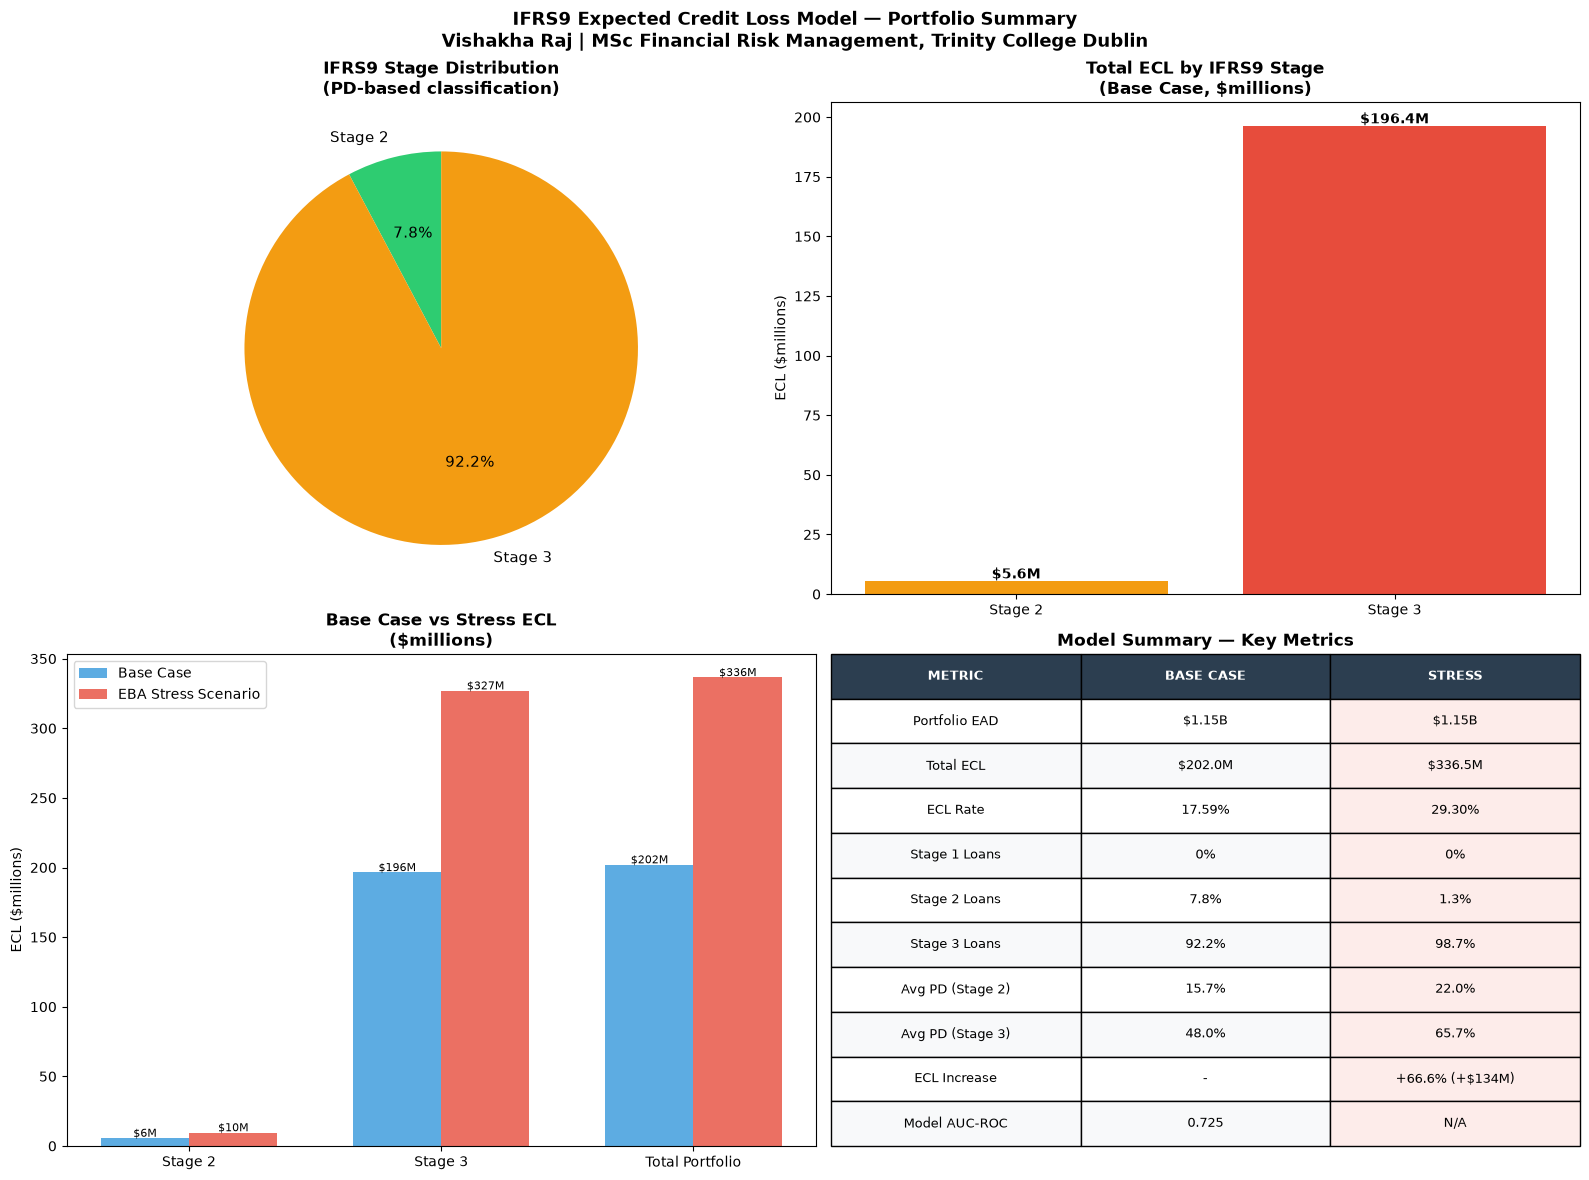


Final summary chart saved as ecl_final_summary.png

PROJECT 1 COMPLETE
Total loans modelled:     78,251
Model AUC-ROC:            0.725
Portfolio EAD:            $1.15 billion
Base Case ECL:            $201,994,919 (17.59%)
Stressed ECL:             $336,484,451 (29.30%)
Stress ECL increase:      +66.6% / +$134.5M
Stage 2→3 migration:      4,258 loans (70.2%)


In [12]:
# ============================================
# MILESTONE 5 - FINAL VISUALISATIONS
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    'IFRS9 Expected Credit Loss Model — Portfolio Summary\n'
    'Vishakha Raj | MSc Financial Risk Management, Trinity College Dublin',
    fontsize=13, fontweight='bold'
)

# --- CHART 1: IFRS9 Stage Distribution ---
stage_data = df['ifrs9_stage'].value_counts().sort_index()
colors_stage = ['#2ecc71', '#f39c12', '#e74c3c']
wedges, texts, autotexts = axes[0,0].pie(
    stage_data.values,
    labels=[f'Stage {i}' for i in stage_data.index],
    colors=colors_stage,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 11}
)
axes[0,0].set_title('IFRS9 Stage Distribution\n(PD-based classification)', 
                     fontweight='bold')

# --- CHART 2: ECL by Stage (Base Case) ---
ecl_by_stage = df.groupby('ifrs9_stage')['ecl_base'].sum() / 1e6
bar_colors = ['#f39c12', '#e74c3c']
bars = axes[0,1].bar(
    [f'Stage {i}' for i in ecl_by_stage.index],
    ecl_by_stage.values,
    color=bar_colors
)
axes[0,1].set_title('Total ECL by IFRS9 Stage\n(Base Case, $millions)', 
                     fontweight='bold')
axes[0,1].set_ylabel('ECL ($millions)')
for bar, val in zip(bars, ecl_by_stage.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, 
                   bar.get_height() + 1,
                   f'${val:.1f}M', ha='center', fontweight='bold')

# --- CHART 3: Base vs Stress ECL Comparison ---
categories = ['Stage 2', 'Stage 3', 'Total Portfolio']
base_values = [
    df[df['ifrs9_stage']==2]['ecl_base'].sum()/1e6,
    df[df['ifrs9_stage']==3]['ecl_base'].sum()/1e6,
    df['ecl_base'].sum()/1e6
]
stress_values = [
    df[df['ifrs9_stage']==2]['ecl_stress'].sum()/1e6,
    df[df['ifrs9_stage']==3]['ecl_stress'].sum()/1e6,
    df['ecl_stress'].sum()/1e6
]

x = np.arange(len(categories))
width = 0.35
bars1 = axes[1,0].bar(x - width/2, base_values, width, 
                       label='Base Case', color='#3498db', alpha=0.8)
bars2 = axes[1,0].bar(x + width/2, stress_values, width,
                       label='EBA Stress Scenario', color='#e74c3c', alpha=0.8)
axes[1,0].set_title('Base Case vs Stress ECL\n($millions)', fontweight='bold')
axes[1,0].set_ylabel('ECL ($millions)')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(categories)
axes[1,0].legend()
for bar in bars1:
    axes[1,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 1,
                   f'${bar.get_height():.0f}M', 
                   ha='center', fontsize=8)
for bar in bars2:
    axes[1,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 1,
                   f'${bar.get_height():.0f}M',
                   ha='center', fontsize=8)

# --- CHART 4: Key Metrics Summary Table ---
axes[1,1].axis('off')
summary_data = [
    ['METRIC', 'BASE CASE', 'STRESS'],
    ['Portfolio EAD', '$1.15B', '$1.15B'],
    ['Total ECL', '$202.0M', '$336.5M'],
    ['ECL Rate', '17.59%', '29.30%'],
    ['Stage 1 Loans', '0%', '0%'],
    ['Stage 2 Loans', '7.8%', '1.3%'],
    ['Stage 3 Loans', '92.2%', '98.7%'],
    ['Avg PD (Stage 2)', '15.7%', '22.0%'],
    ['Avg PD (Stage 3)', '48.0%', '65.7%'],
    ['ECL Increase', '-', '+66.6% (+$134M)'],
    ['Model AUC-ROC', '0.725', 'N/A'],
]

table = axes[1,1].table(
    cellText=summary_data[1:],
    colLabels=summary_data[0],
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(9)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif col == 2 and row > 0:
        cell.set_facecolor('#fdecea')
    elif row % 2 == 0:
        cell.set_facecolor('#f8f9fa')
axes[1,1].set_title('Model Summary — Key Metrics', fontweight='bold')

plt.tight_layout()
plt.savefig('ecl_final_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nFinal summary chart saved as ecl_final_summary.png")
print("\n" + "="*55)
print("PROJECT 1 COMPLETE")
print("="*55)
print(f"Total loans modelled:     {len(df):,}")
print(f"Model AUC-ROC:            0.725")
print(f"Portfolio EAD:            $1.15 billion")
print(f"Base Case ECL:            $201,994,919 (17.59%)")
print(f"Stressed ECL:             $336,484,451 (29.30%)")
print(f"Stress ECL increase:      +66.6% / +$134.5M")
print(f"Stage 2→3 migration:      4,258 loans (70.2%)")
print("="*55)